In [ ]:
#required for word2vec
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.4 MB/s eta 0:00:00


# Download Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [ ]:
import os

os.listdir(path)

['True.csv', 'Fake.csv']




# Import libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.colors import ListedColormap
from wordcloud import WordCloud, STOPWORDS
import re
import string
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA


import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score, f1_score
from sklearn import metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# Reading Data

In [ ]:
true_df = pd.read_csv(f'{path}/True.csv')
fake_df = pd.read_csv(f'{path}/Fake.csv')

In [ ]:
true_df.head(10)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


In [ ]:
fake_df.head(5)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


# Merge Datasets

In [ ]:
true_df['target']=1
fake_df['target']=0
df=pd.concat([true_df,fake_df], ignore_index=True)

In [ ]:
df.head(5)

,title,text,subject,date,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [ ]:
#merge title and text columns in one column called content
df['content'] = df['title'] + " " + df['text']
df.drop(['title','text'], axis=1, inplace=True)
df.head(5)

,subject,date,target,content
0,politicsNews,"December 31, 2017",1,"As U.S. budget fight looms, Republicans flip t..."
1,politicsNews,"December 29, 2017",1,U.S. military to accept transgender recruits o...
2,politicsNews,"December 31, 2017",1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,politicsNews,"December 30, 2017",1,FBI Russia probe helped by Australian diplomat...
4,politicsNews,"December 29, 2017",1,Trump wants Postal Service to charge 'much mor...


# Visualization

## Class Distribution

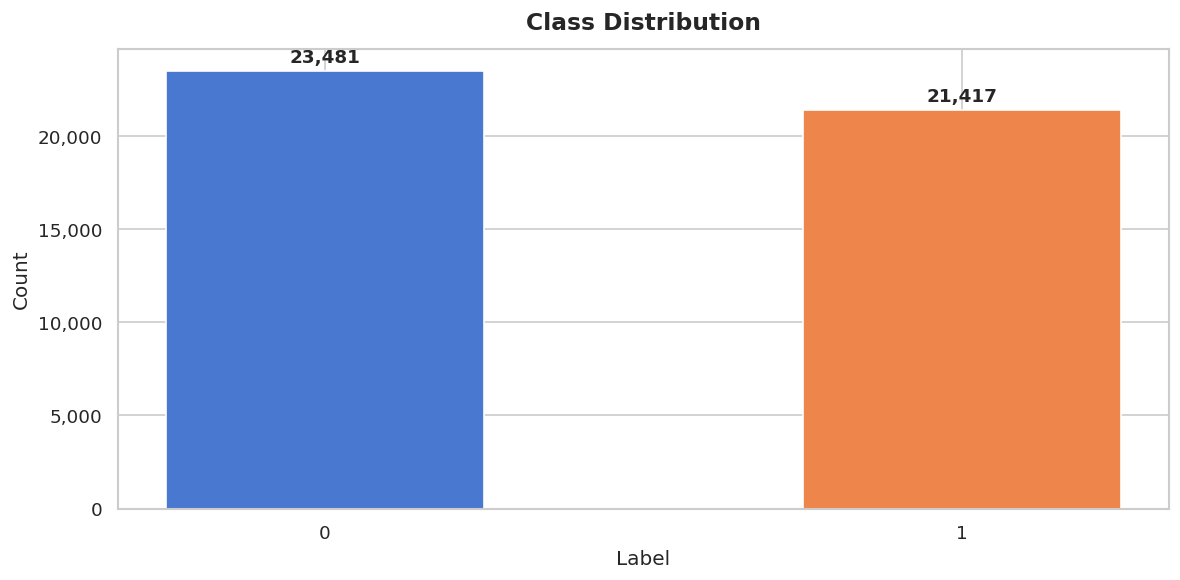

In [ ]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots()
counts = df['target'].value_counts().sort_index()

bars = ax.bar(counts.index.astype(str), counts.values,
              color=sns.color_palette('muted', len(counts)), edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Word Cloud Visualization

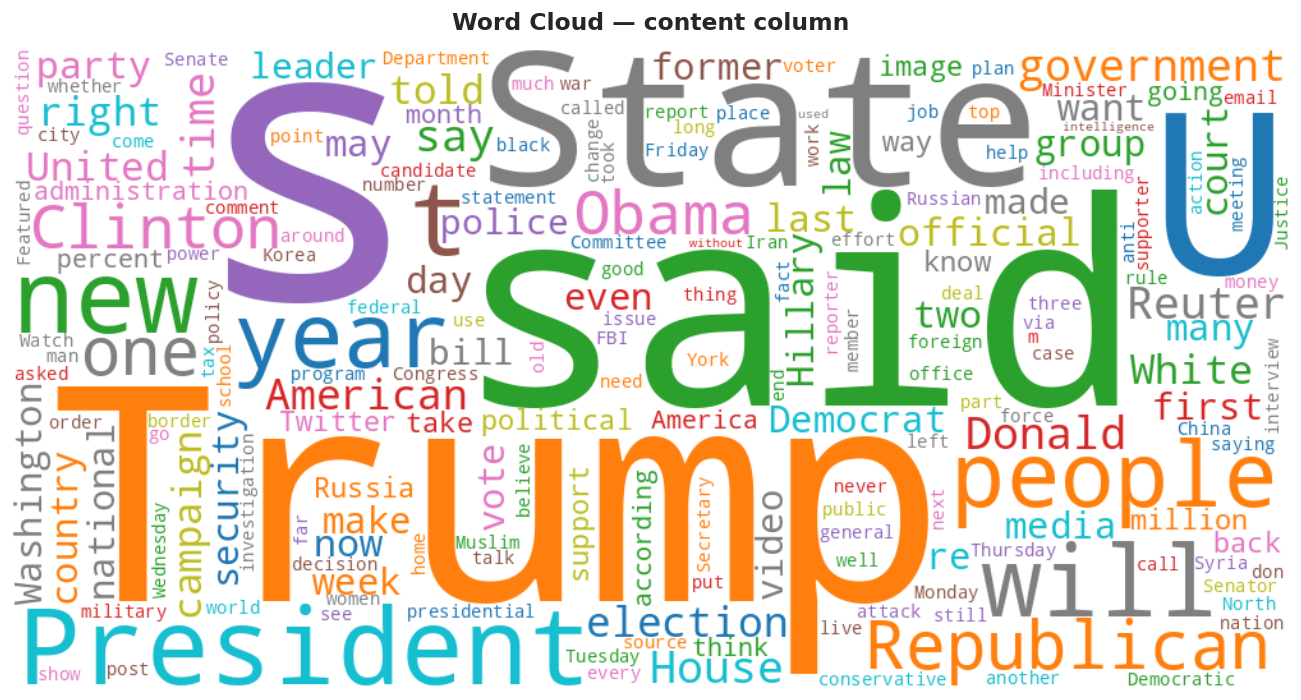

In [ ]:
text_blob = ' '.join(df['content'].dropna().astype(str).tolist())

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=200,
    colormap='tab10',
    collocations=False
).generate(text_blob)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — content column', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Top 20 Most Frequent Words

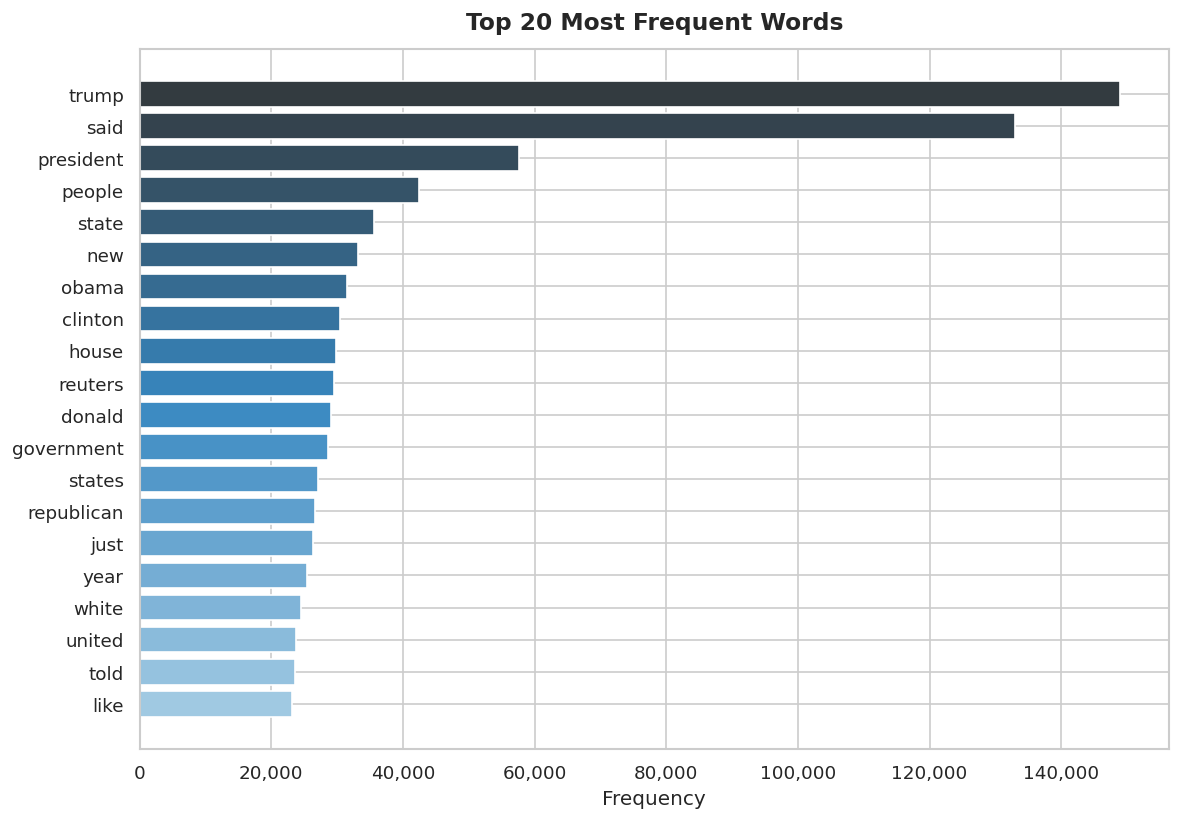

In [ ]:
cv = CountVectorizer(stop_words='english', max_features=20000)
cv.fit(df['content'].dropna().astype(str))
X = cv.transform(df['content'].dropna().astype(str))

word_freq = pd.Series(np.asarray(X.sum(axis=0)).flatten(),
                      index=cv.get_feature_names_out())
top20 = word_freq.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Blues_d', len(top20))
ax.barh(top20.index, top20.values, color=colors, edgecolor='white')
ax.set_title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Frequency', fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Top 15 Bigrams

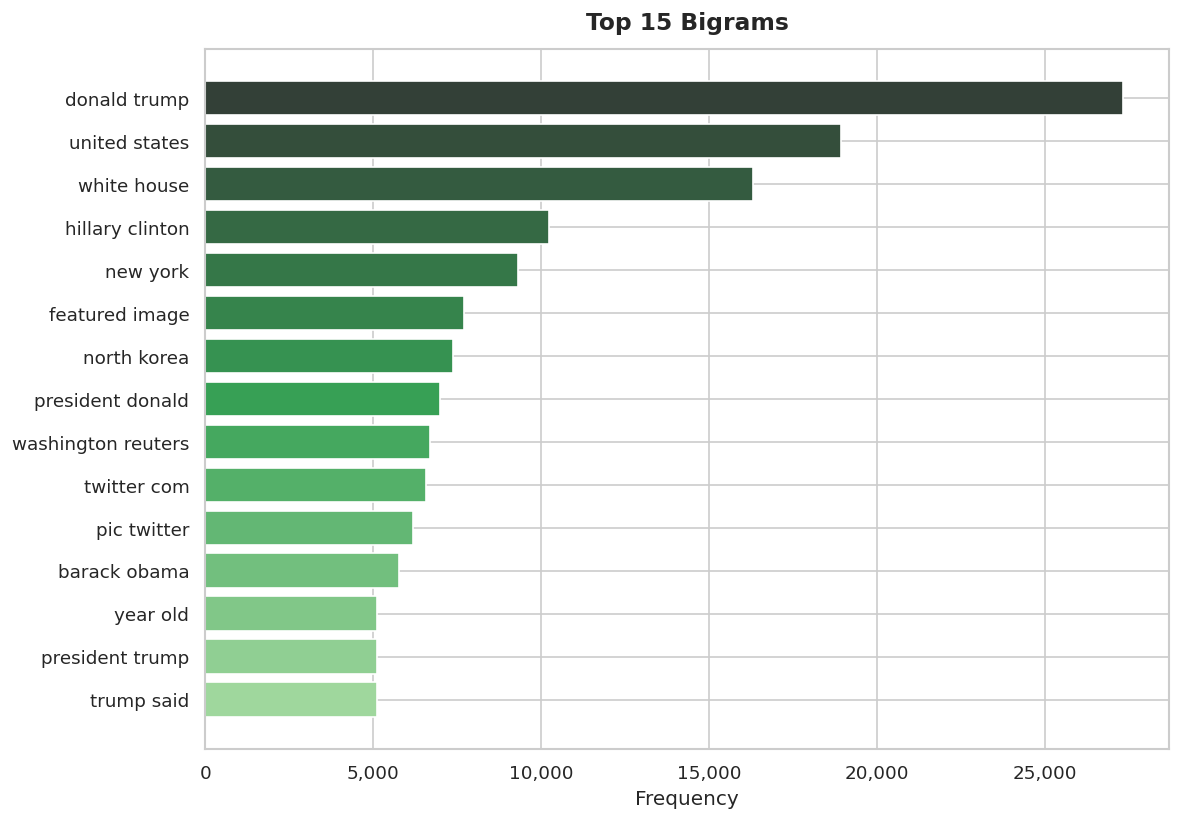

In [ ]:
bgv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=50000)
bgv.fit(df['content'].dropna().astype(str))
Xb = bgv.transform(df['content'].dropna().astype(str))

bigram_freq = pd.Series(np.asarray(Xb.sum(axis=0)).flatten(),
                        index=bgv.get_feature_names_out())
top15 = bigram_freq.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Greens_d', len(top15))
ax.barh(top15.index, top15.values, color=colors, edgecolor='white')
ax.set_title('Top 15 Bigrams', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Frequency', fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## TF-IDF + PCA — 2D Text Visualization

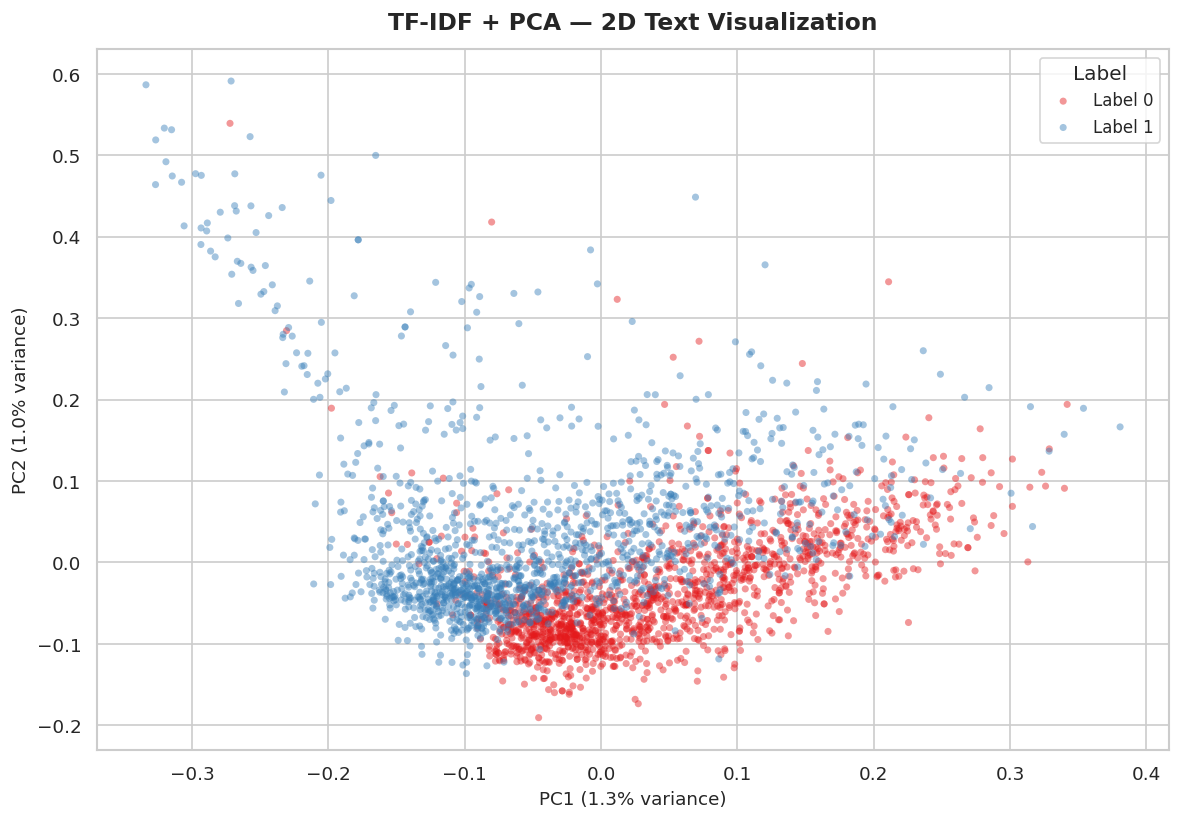

In [ ]:
# Sample for speed — remove/increase if your hardware allows
sample = df[['content', 'target']].dropna().sample(min(3000, len(df)), random_state=42)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(sample['content'].astype(str))

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_tfidf.toarray())

plot_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'label': sample['target'].values
})

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('Set1', plot_df['label'].nunique())

for idx, (lbl, grp) in enumerate(plot_df.groupby('label')):
    ax.scatter(grp['PC1'], grp['PC2'],
               label=f'Label {lbl}',
               color=palette[idx],
               alpha=0.45, s=18, edgecolors='none')

var = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]:.1%} variance)', fontsize=11)
ax.set_title('TF-IDF + PCA — 2D Text Visualization', fontsize=14, fontweight='bold', pad=12)
ax.legend(title='Label', fontsize=10)
plt.tight_layout()
plt.show()

# Preprocessing


## removing URLS & Standardize distances






In [ ]:
def basic_clean(text):
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text=re.sub(r'\W', ' ', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    return text.strip()

df['content'] = df['content'].apply(basic_clean)

In [ ]:
df.duplicated().sum()

np.int64(213)

In [ ]:
df.drop_duplicates(inplace=True)

## Lowercasing

In [ ]:
df['content'] = df['content'].str.lower()

## Word Tokenization

In [ ]:

df['tokens']=df['content'].apply(word_tokenize)

## Stop Words Removal with keeping negative words

In [ ]:
english_stopwords = set(stopwords.words("english")) #set of famous stopwords in english

#removeing negative words from set
for neg_word in ["not", "no", "never","don't","doesn't"]:
    if neg_word in english_stopwords:
        english_stopwords.remove(neg_word)

def remove_stopwords(tokens):
    return [tok for tok in tokens if tok not in english_stopwords]

df["tokens_no_stop"] = df["tokens"].apply(remove_stopwords)

## Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(tok) for tok in tokens]


df["lemmatized_tokens"] = df["tokens_no_stop"].apply(apply_lemmatization)

# Embedding Part

## Word2Vec Model

In [ ]:
#Creating a corpus of lemmatized text
#df["corpus"] = df["lemmatized_tokens"].apply(lambda x: " ".join(x))

In [ ]:
X = df["lemmatized_tokens"]
y = df["target"]

In [ ]:
# Splitting the testing and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Word2Vec(sentences=X_train, vector_size=150, window=5, min_count=1, workers=4)

## Embedding

In [ ]:
def get_sentence_embedding(tokens, model, vector_size):
    embeddings = []
    for word in tokens:
        if word in model.wv:
            embeddings.append(model.wv[word])
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(vector_size)

In [ ]:
train_embedding = np.array([get_sentence_embedding(tokens, model, 150) for tokens in X_train])

In [ ]:
test_embedding = np.array([get_sentence_embedding(tokens, model, 150) for tokens in X_test])

# Machine Learning Model

In [ ]:
classifiers = [XGBClassifier(),
               RandomForestClassifier(),
               SVC()]

for model in classifiers:
    model.fit(train_embedding, y_train)

In [ ]:
# Model Evaluation
# creating lists of varios scores
precision =[]
recall =[]
f1_score = []
testset_accuracy = []

for i in classifiers:
    pred_test = i.predict(test_embedding)
    prec = metrics.precision_score(y_test, pred_test)
    recal = metrics.recall_score(y_test, pred_test)
    f1_s = metrics.f1_score(y_test, pred_test)
    test_accuracy = i.score(test_embedding,y_test)

    #Appending scores
    precision.append(prec)
    recall.append(recal)
    f1_score.append(f1_s)
    testset_accuracy.append(test_accuracy)

In [ ]:
# initialise data of lists.
data = {'Precision':precision,
'Recall':recall,
'F1score':f1_score,
'Accuracy ':testset_accuracy,}
# Creates pandas DataFrame.
Results = pd.DataFrame(data, index =["XGBoostClassifier", "RandomForest","SVC"])

In [ ]:
from matplotlib.colors import ListedColormap
cmap2 = ListedColormap(["#F3E5F5","#CE93D8"])
Results.style.background_gradient(cmap=cmap2)

,Precision,Recall,F1score,Accuracy
XGBoostClassifier,0.983829,0.978555,0.981185,0.981985
RandomForest,0.971603,0.965035,0.968308,0.969677
SVC,0.983485,0.985548,0.984515,0.985118


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4647
           1       0.98      0.99      0.98      4290

    accuracy                           0.99      8937
   macro avg       0.99      0.99      0.99      8937
weighted avg       0.99      0.99      0.99      8937



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred_test)

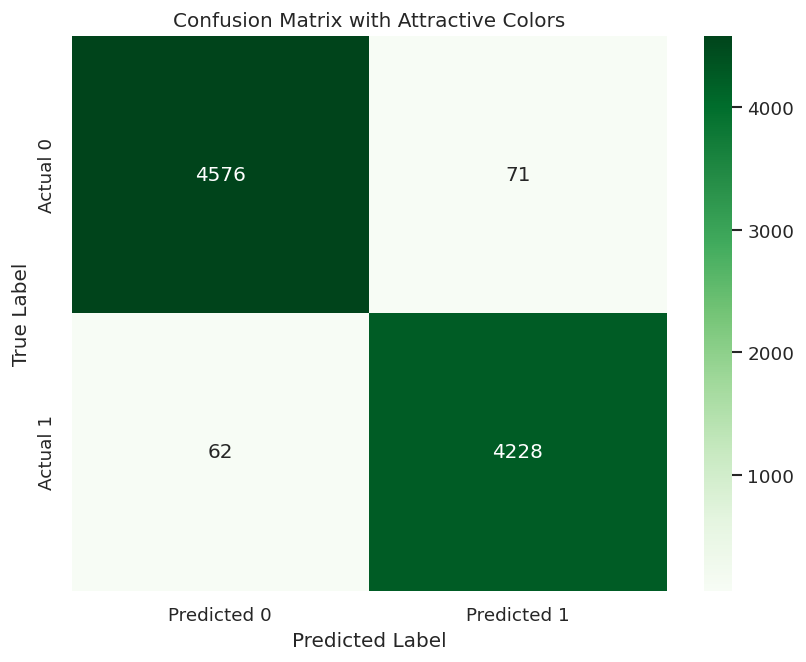

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix ')
plt.show()

# Deep Learning

## Preprocessing

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def process_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # keep only letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = word_tokenize(text)

    # remove stopwords + short words + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    # return cleaned sentence
    return " ".join(words)

In [ ]:
df['content']=df['content'].apply(process_text)

In [ ]:
X = df["content"]
y = df["target"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Building and training model

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 618s 680ms/step - accuracy: 0.8653 - loss: 0.3624 - val_accuracy: 0.9291 - val_loss: 0.2585
Epoch 2/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 599s 670ms/step - accuracy: 0.9190 - loss: 0.2549 - val_accuracy: 0.8141 - val_loss: 0.4023
Epoch 3/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 603s 674ms/step - accuracy: 0.9149 - loss: 0.2239 - val_accuracy: 0.9599 - val_loss: 0.1246
Epoch 4/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 622s 696ms/step - accuracy: 0.9746 - loss: 0.0863 - val_accuracy: 0.9797 - val_loss: 0.0665
Epoch 5/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 603s 674ms/step - accuracy: 0.9870 - loss: 0.0517 - val_accuracy: 0.9832 - val_loss: 0.0676


In [ ]:
model.save("fake_news_model.keras")

## Evaluation

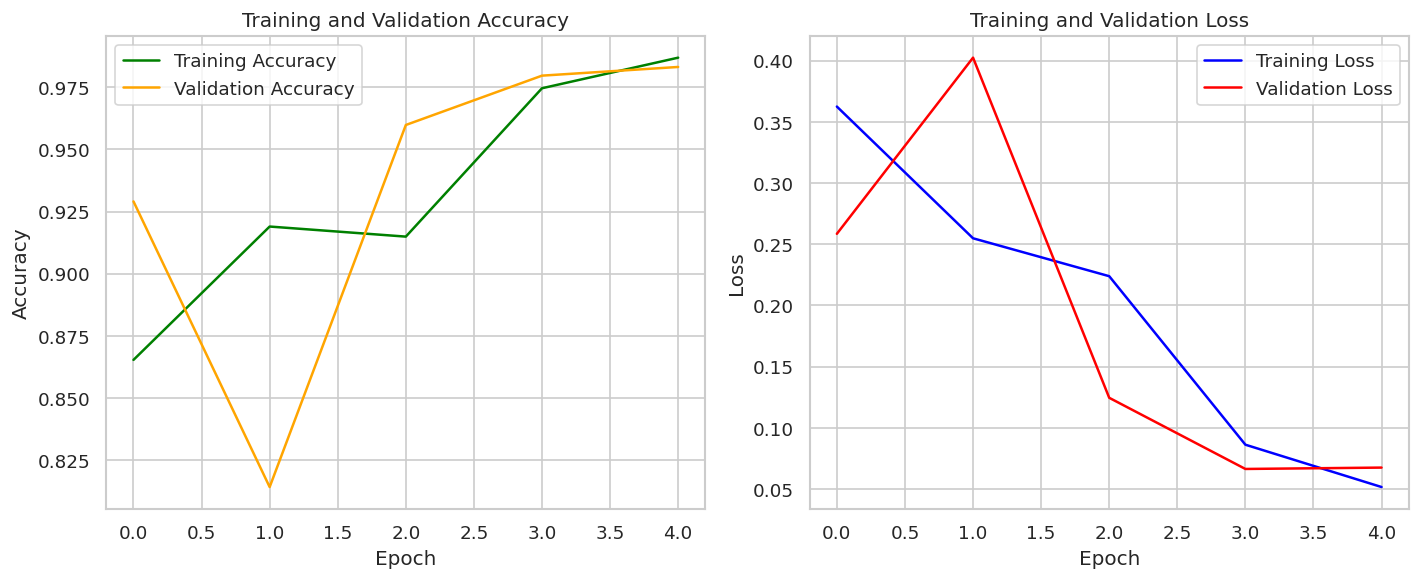

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(x_test_pad, y_test)

print("Accuracy:", accuracy)

280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.9825 - loss: 0.0641
Accuracy: 0.982544481754303


280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 126ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4647
           1       0.99      0.97      0.98      4290

    accuracy                           0.98      8937
   macro avg       0.98      0.98      0.98      8937
weighted avg       0.98      0.98      0.98      8937



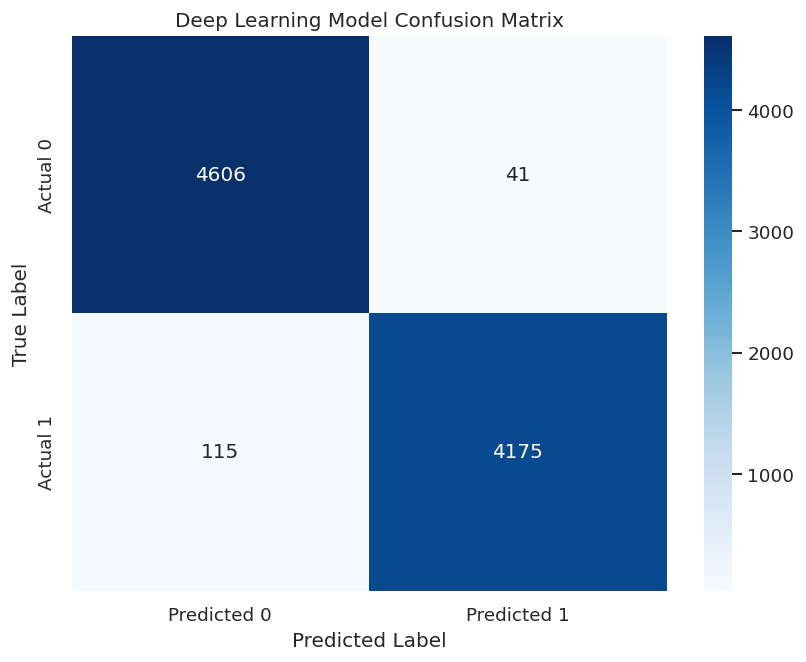

In [ ]:
prediction_on_test_set = model.predict(x_test_pad)
y_pred = (prediction_on_test_set > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm_dl = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Deep Learning Model Confusion Matrix')
plt.show()

## Prediction on New Text

In [ ]:
news = ["Government confirms new economic plan"]

seq = tokenizer.texts_to_sequences(news)

pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

prediction = model.predict(pad)

if prediction[0][0] > 0.5:
    print("Real News")
else:
    print("Fake News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
Real News
